# Causal ML example



In [202]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from econml.dml import LinearDML

np.random.seed(42)

## Make data

In [203]:
n_samples = 10000

n_X = 2

## Features
X = np.random.normal(size=(n_samples, n_X))

## Correlated (no confounder)

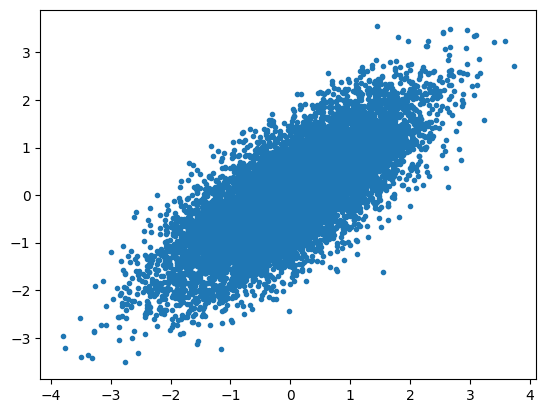

In [204]:
## Treatments (correlated)

# Mean vector (mu)
mu = [0, 0]

# Define the covariance matrix (Sigma)
Sigma = [[1, 0.75], 
         [0.75, 1]]

# Generate the samples
samples = np.random.multivariate_normal(mean=mu, cov=Sigma, size=n_samples)

T0 = samples[:,0]
T1 = samples[:,1]


plt.plot(samples[:,0], samples[:,1], '.')
# plt.hexbin(samples[:,0], samples[:,1], gridsize=50)


In [205]:
## Outcome
bT0 = 3
bT1 = -5
bT0T1 = 1.5
bX1 = 1

Y = bT0 * T0 + bT1 * T1 + bX1 * X[:,0] + np.random.normal(0.0, 1.0, size=(n_samples), )

In [206]:
# Create a dictionary where keys are column names and values are arrays
data_dict = {'X0': X[:,0], 
             'X1': X[:,1], 
             'T0': T0, 
             'T1': T1, 
             'y': Y}

# Create the DataFrame from the dictionary
df = pd.DataFrame(data_dict)

In [207]:
## Model 1
model = smf.ols(formula='y ~ T0 + T1', data = df)
results = model.fit()
# print(results.summary()) # View the regression results summary
results.params

Intercept    0.010337
T0           2.976272
T1          -5.022623
dtype: float64

In [208]:
## Model 2
model = smf.ols(formula='y ~ T0 + T1 + X0', data = df)
results = model.fit()
# print(results.summary()) # View the regression results summary
results.params

Intercept    0.006486
T0           2.998206
T1          -5.009064
X0           1.015126
dtype: float64

## Correlated (w/ confounder)

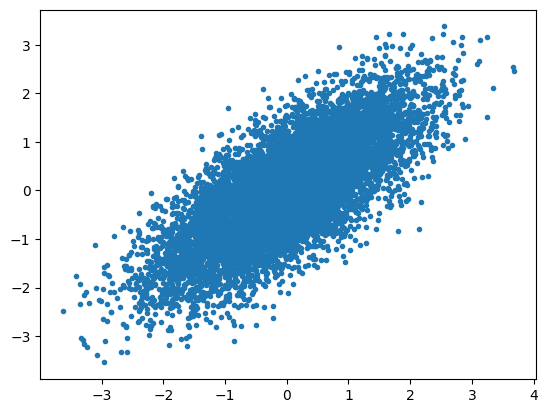

In [209]:
## Treatments (correlated)

# Mean vector (mu)
mu = [0, 0]

# Define the covariance matrix (Sigma)
Sigma = [[1, 0.75], 
         [0.75, 1]]

# Generate the samples
samples = np.random.multivariate_normal(mean=mu, cov=Sigma, size=n_samples)

bT0X = 2
bT1X = 3

T0 = samples[:,0] + bT0X * X[:,0]
T1 = samples[:,1] + bT1X * X[:,0]


plt.plot(samples[:,0], samples[:,1], '.')
# plt.hexbin(samples[:,0], samples[:,1], gridsize=50)


In [210]:
## Outcome
bT0 = 3
bT1 = -5
bT0T1 = 1.5
bX1 = 1

Y = bT0 * T0 + bT1 * T1 + bX1 * X[:,0] + np.random.normal(0.0, 1.0, size=(n_samples), )

In [211]:
# Create a dictionary where keys are column names and values are arrays
data_dict = {'X0': X[:,0], 
             'X1': X[:,1], 
             'T0': T0, 
             'T1': T1, 
             'y': Y}

# Create the DataFrame from the dictionary
df = pd.DataFrame(data_dict)

In [212]:
## Model 1
model = smf.ols(formula='y ~ T0 + T1', data = df)
results = model.fit()
# print(results.summary()) # View the regression results summary
results.params

Intercept    0.001180
T0           2.961548
T1          -4.674568
dtype: float64

In [213]:
## Model 2
model = smf.ols(formula='y ~ T0 + T1 + X', data = df)
results = model.fit()
# print(results.summary()) # View the regression results summary
results.params

Intercept   -0.001402
T0           3.017537
T1          -5.036342
X[0]         1.080295
X[1]        -0.007254
dtype: float64

## Linear DML

In [214]:
T = np.vstack((T0,T1)).T

### Model 1

In [215]:
est = LinearDML(
    model_y='linear',
    model_t='linear',
    discrete_treatment=False
)

### No confounder

In [216]:
# Fit the model
est.fit(Y, T)
est.marginal_ate_inference(T)

### Confounder

In [217]:
# Fit the model
est.fit(Y, T, W=X)
est.marginal_ate_inference(T)